- Đề tài: Phân tích các chỉ số sức khỏe và dự đoán nguy cơ mắc bệnh tim
- Dataset: UCI Heart Disease (Cleveland), 303 mẫu, 14 features
- Bài toán: Statistical Analysis — tìm hiểu mối liên hệ giữa các 
  chỉ số sức khỏe (tuổi, cholesterol, huyết áp...) với nguy cơ 
  mắc bệnh tim; kiểm định giả thuyết thống kê
- Không phải bài toán classification thuần túy — tập trung vào 
  EDA và statistical inference

In [3]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [4]:
#Tải UCI Heart Disease dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
           'restecg', 'thalach', 'exang', 'oldpeak',
           'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, header=None, names=columns, na_values='?')

# Chuyển target về binary (0 = không bệnh, 1 = có bệnh)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f"Dataset loaded: {df.shape[0]} dòng, {df.shape[1]} cột")
df.head()

Dataset loaded: 303 dòng, 14 cột


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Phân tích các chỉ số sức khỏe và dự đoán nguy cơ mắc bệnh tim

## 1. Giới thiệu bài toán

### Bối cảnh
Bệnh tim mạch là nguyên nhân gây tử vong hàng đầu trên thế giới. Việc 
phân tích các chỉ số sức khỏe để hiểu yếu tố nguy cơ là bước quan trọng 
trong y tế dự phòng.

### Dataset
- **Nguồn**: UCI Machine Learning Repository — Cleveland Heart Disease
- **Kích thước**: 303 mẫu, 14 features
- **Target**: Có/không có bệnh tim (binary)

### Mục tiêu phân tích
1. Mô tả phân phối của các chỉ số sức khỏe trong dataset
2. Kiểm tra sự khác biệt giữa nhóm có và không có bệnh tim
3. Xác định các yếu tố có liên quan thống kê đến nguy cơ bệnh tim
4. Ước lượng confidence interval cho các chỉ số quan trọng

### Loại bài toán
**Statistical Analysis** — tập trung vào EDA, hypothesis testing, 
sampling distribution và bootstrap confidence interval, classification

In [5]:
# Tổng quan dataset
print("=" * 55)
print("TỔNG QUAN DATASET")
print("=" * 55)

print(f"\n Kích thước: {df.shape[0]} mẫu × {df.shape[1]} features")
print(f"\n Phân bố target:")
counts = df['target'].value_counts()
for val, count in counts.items():
    label = "Có bệnh tim" if val == 1 else "Không bệnh tim"
    pct = count / len(df) * 100
    print(f"   {label} ({val}): {count} mẫu ({pct:.1f}%)")

print(f"\n Kiểu dữ liệu:")
print(df.dtypes)

print(f"\n Missing values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "   Không có missing values rõ ràng")

TỔNG QUAN DATASET

 Kích thước: 303 mẫu × 14 features

 Phân bố target:
   Không bệnh tim (0): 164 mẫu (54.1%)
   Có bệnh tim (1): 139 mẫu (45.9%)

 Kiểu dữ liệu:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

 Missing values:
ca      4
thal    2
dtype: int64


In [6]:
# Bảng mô tả ý nghĩa từng feature
feature_info = {
    'Feature':      ['age','sex','cp','trestbps','chol','fbs',
                     'restecg','thalach','exang','oldpeak','slope','ca','thal','target'],
    'Tên đầy đủ':  ['Tuổi','Giới tính','Loại đau ngực','Huyết áp lúc nghỉ',
                     'Cholesterol','Đường huyết lúc đói','Kết quả ECG',
                     'Nhịp tim tối đa','Đau ngực khi gắng sức','ST depression',
                     'Độ dốc ST','Số mạch chính','Thalassemia','Có bệnh tim'],
    'Loại':        ['Numeric','Binary','Categorical','Numeric','Numeric','Binary',
                     'Categorical','Numeric','Binary','Numeric',
                     'Categorical','Categorical','Categorical','Binary'],
    'Ghi chú':     ['năm','1=Nam, 0=Nữ','0–3','mmHg','mg/dl','>120mg/dl=1',
                     '0–2','bpm','1=Có','0–6.2','0–2','0–3','1/2/3','0=Không, 1=Có']
}

df_info = pd.DataFrame(feature_info)
df_info

,Feature,Tên đầy đủ,Loại,Ghi chú
0,age,Tuổi,Numeric,năm
1,sex,Giới tính,Binary,"1=Nam, 0=Nữ"
2,cp,Loại đau ngực,Categorical,0–3
3,trestbps,Huyết áp lúc nghỉ,Numeric,mmHg
4,chol,Cholesterol,Numeric,mg/dl
5,fbs,Đường huyết lúc đói,Binary,>120mg/dl=1
6,restecg,Kết quả ECG,Categorical,0–2
7,thalach,Nhịp tim tối đa,Numeric,bpm
8,exang,Đau ngực khi gắng sức,Binary,1=Có
9,oldpeak,ST depression,Numeric,0–6.2


In [7]:
#Thống kê mô tả
print("THỐNG KÊ MÔ TẢ — BIẾN NUMERIC")
print("=" * 55)

numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[numeric_cols].describe().round(2)

THỐNG KÊ MÔ TẢ — BIẾN NUMERIC


,age,trestbps,chol,thalach,oldpeak
count,303.00,303.00,303.00,303.00,303.00
mean,54.44,131.69,246.69,149.61,1.04
std,9.04,17.60,51.78,22.88,1.16
min,29.00,94.00,126.00,71.00,0.00
25%,48.00,120.00,211.00,133.50,0.00
50%,56.00,130.00,241.00,153.00,0.80
75%,61.00,140.00,275.00,166.00,1.60
max,77.00,200.00,564.00,202.00,6.20


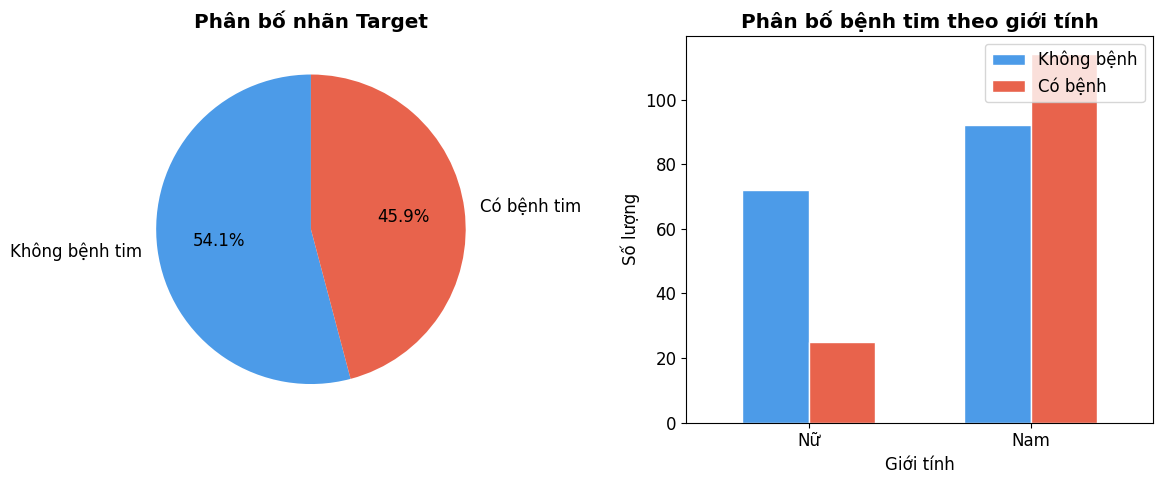

Đã lưu: 01_target_distribution.png


In [8]:
# Visualize phân bố target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
labels = ['Không bệnh tim', 'Có bệnh tim']
colors = ['#4C9BE8', '#E8634C']
sizes  = df['target'].value_counts().sort_index().values
axes[0].pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Phân bố nhãn Target', fontweight='bold')

# Bar chart theo giới tính
sex_target = df.groupby(['sex', 'target']).size().unstack()
sex_target.index = ['Nữ', 'Nam']
sex_target.columns = ['Không bệnh', 'Có bệnh']
sex_target.plot(kind='bar', ax=axes[1],
                color=['#4C9BE8', '#E8634C'],
                edgecolor='white', width=0.6)
axes[1].set_title('Phân bố bệnh tim theo giới tính', fontweight='bold')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Số lượng')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: 01_target_distribution.png")

# Tiền xử lý dữ liệu

In [9]:
# Xử lý missing values
print("TRƯỚC KHI XỬ LÝ:")
print(df[['ca', 'thal']].isnull().sum())
print(f"Tổng số dòng: {len(df)}")

# ca và thal là categorical → dùng mode (giá trị phổ biến nhất)
df['ca']   = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

print("\nSAU KHI XỬ LÝ:")
print(df.isnull().sum().sum(), "missing values còn lại")
print("Đã điền missing values bằng mode")

TRƯỚC KHI XỬ LÝ:
ca      4
thal    2
dtype: int64
Tổng số dòng: 303

SAU KHI XỬ LÝ:
0 missing values còn lại
Đã điền missing values bằng mode


In [10]:
# Ép kiểu — categorical về int, numeric giữ nguyên float
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numeric_cols     = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in categorical_cols:
    df[col] = df[col].astype(int)

print("Kiểu dữ liệu sau khi ép:")
print(df.dtypes)
print("\n Hoàn tất ép kiểu")

Kiểu dữ liệu sau khi ép:
age         float64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

 Hoàn tất ép kiểu


KIỂM TRA OUTLIERS (phương pháp IQR)
age        | Khoảng hợp lệ: [28.5, 80.5] | Outliers: 0
trestbps   | Khoảng hợp lệ: [90.0, 170.0] | Outliers: 9
chol       | Khoảng hợp lệ: [115.0, 371.0] | Outliers: 5
thalach    | Khoảng hợp lệ: [84.8, 214.8] | Outliers: 1
oldpeak    | Khoảng hợp lệ: [-2.4, 4.0] | Outliers: 5


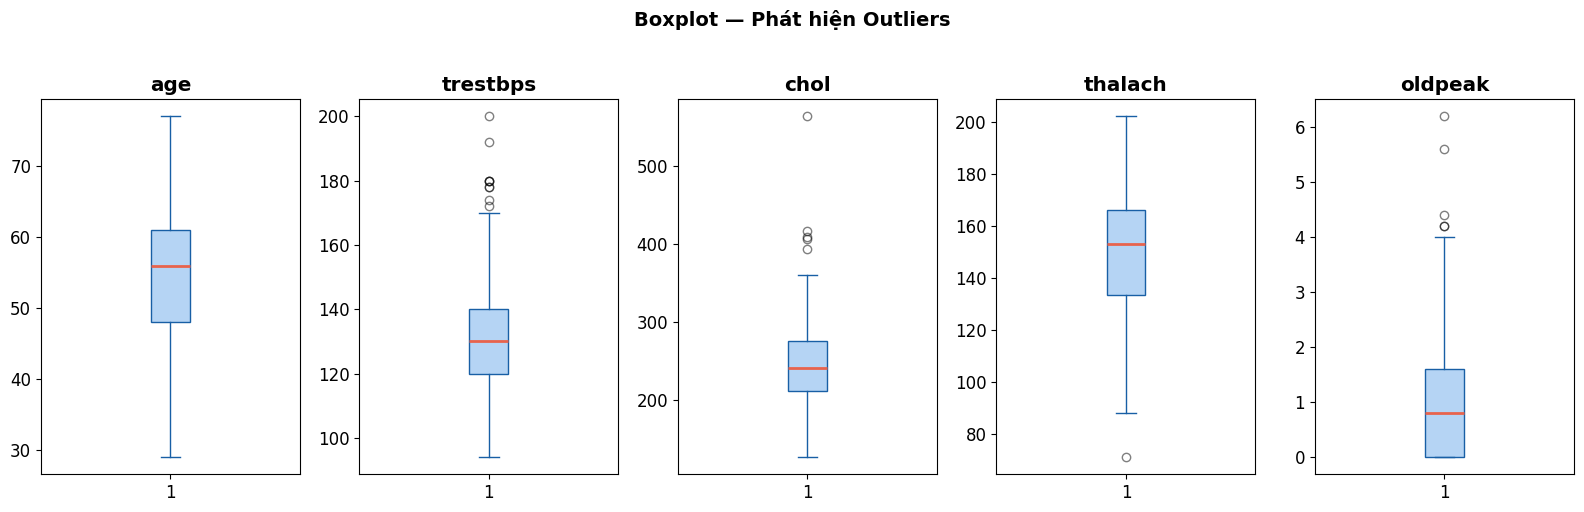

 Đã lưu: 02_outliers_boxplot.png


In [11]:
# Phát hiện outliers bằng IQR
print("KIỂM TRA OUTLIERS (phương pháp IQR)")
print("=" * 45)

outlier_summary = []

for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Feature': col, 'Q1': Q1, 'Q3': Q3,
        'Lower bound': round(lower, 1),
        'Upper bound': round(upper, 1),
        'Số outliers': n_out
    })
    print(f"{col:10s} | Khoảng hợp lệ: [{lower:.1f}, {upper:.1f}] | Outliers: {n_out}")

# Visualize boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                    medianprops=dict(color='#E8634C', linewidth=2),
                    whiskerprops=dict(color='#185FA5'),
                    capprops=dict(color='#185FA5'),
                    flierprops=dict(marker='o', color='#E8634C', alpha=0.5))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplot — Phát hiện Outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu: 02_outliers_boxplot.png")

In [12]:
# Quyết đinh giữ ouliers
# Giữ nguyên outliers
# 
# LÝ DO KHÔNG XÓA OUTLIER trong dataset y tế:
# - chol = 564: cholesterol cực cao → đây là ca bệnh thật, không phải lỗi đo
# - trestbps = 200: huyết áp rất cao → dấu hiệu lâm sàng quan trọng
# - Xóa outlier y tế = xóa những ca nặng nhất = gây selection bias
# - Dataset nhỏ (303 mẫu) → mất dữ liệu sẽ ảnh hưởng lớn

print("Quyết định: GIỮ NGUYÊN outliers")
print()
print("Lý do:")
print("  • Dataset y tế: giá trị cực đoan = ca bệnh nặng, không phải lỗi")
print("  • Xóa outlier gây selection bias — loại bỏ đúng nhóm cần nghiên cứu")
print("  • Dataset nhỏ (303 mẫu) — mỗi dòng đều có giá trị")
print("  • Phù hợp với nguyên tắc từ slide: data quality > data quantity")

Quyết định: GIỮ NGUYÊN outliers

Lý do:
  • Dataset y tế: giá trị cực đoan = ca bệnh nặng, không phải lỗi
  • Xóa outlier gây selection bias — loại bỏ đúng nhóm cần nghiên cứu
  • Dataset nhỏ (303 mẫu) — mỗi dòng đều có giá trị
  • Phù hợp với nguyên tắc từ slide: data quality > data quantity


In [13]:
# Chuẩn hóa z-score cho numeric features
# (chỉ dùng để vẽ biểu đồ so sánh, KHÔNG thay thế data gốc)
from sklearn.preprocessing import StandardScaler

df_scaled = df.copy()
scaler = StandardScaler()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Thống kê sau chuẩn hóa (mean ≈ 0, std ≈ 1):")
print(df_scaled[numeric_cols].describe().round(3))
print()
print(" Lưu ý (ghi vào báo cáo):")
print("  • df       = data gốc  → dùng cho thống kê, diễn giải")
print("  • df_scaled = đã chuẩn hóa → dùng cho visualization so sánh scale")

Thống kê sau chuẩn hóa (mean ≈ 0, std ≈ 1):
           age  trestbps     chol  thalach  oldpeak
count  303.000   303.000  303.000  303.000  303.000
mean    -0.000     0.000    0.000   -0.000    0.000
std      1.002     1.002    1.002    1.002    1.002
min     -2.819    -2.145   -2.335   -3.442   -0.897
25%     -0.714    -0.665   -0.691   -0.705   -0.897
50%      0.173    -0.096   -0.110    0.149   -0.207
75%      0.727     0.473    0.548    0.718    0.483
max      2.500     3.888    6.138    2.294    4.452

 Lưu ý (ghi vào báo cáo):
  • df       = data gốc  → dùng cho thống kê, diễn giải
  • df_scaled = đã chuẩn hóa → dùng cho visualization so sánh scale


# Exploratory Data Analysis (EDA)

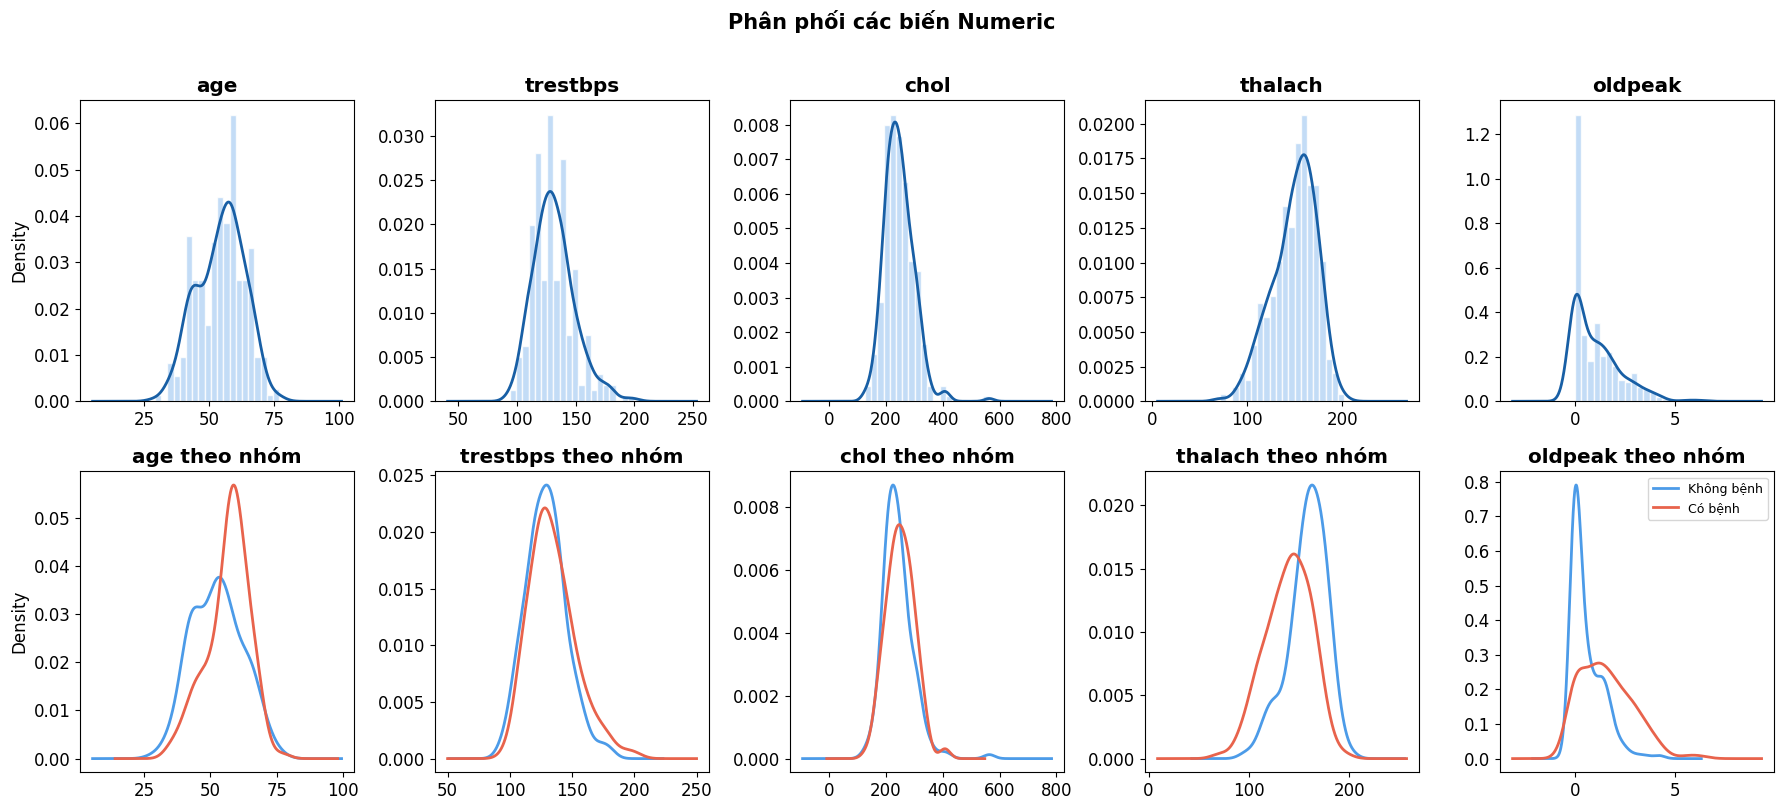

Đã lưu: 03_numeric_distributions.png


In [14]:
# Distribution plot — numeric features
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(numeric_cols):
    # Hàng trên: histogram + KDE toàn bộ
    axes[0, i].hist(df[col], bins=20, color='#B5D4F4',
                    edgecolor='white', density=True, alpha=0.8)
    df[col].plot.kde(ax=axes[0, i], color='#185FA5', linewidth=2)
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_ylabel('Density' if i == 0 else '')

    # Hàng dưới: KDE chia theo target (có/không bệnh)
    for target_val, color, label in zip([0, 1],
                                        ['#4C9BE8', '#E8634C'],
                                        ['Không bệnh', 'Có bệnh']):
        subset = df[df['target'] == target_val][col]
        subset.plot.kde(ax=axes[1, i], color=color,
                        linewidth=2, label=label)
    axes[1, i].set_title(f'{col} theo nhóm', fontweight='bold')
    axes[1, i].set_ylabel('Density' if i == 0 else '')
    if i == 4:
        axes[1, i].legend(fontsize=9)

plt.suptitle('Phân phối các biến Numeric', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: 03_numeric_distributions.png")

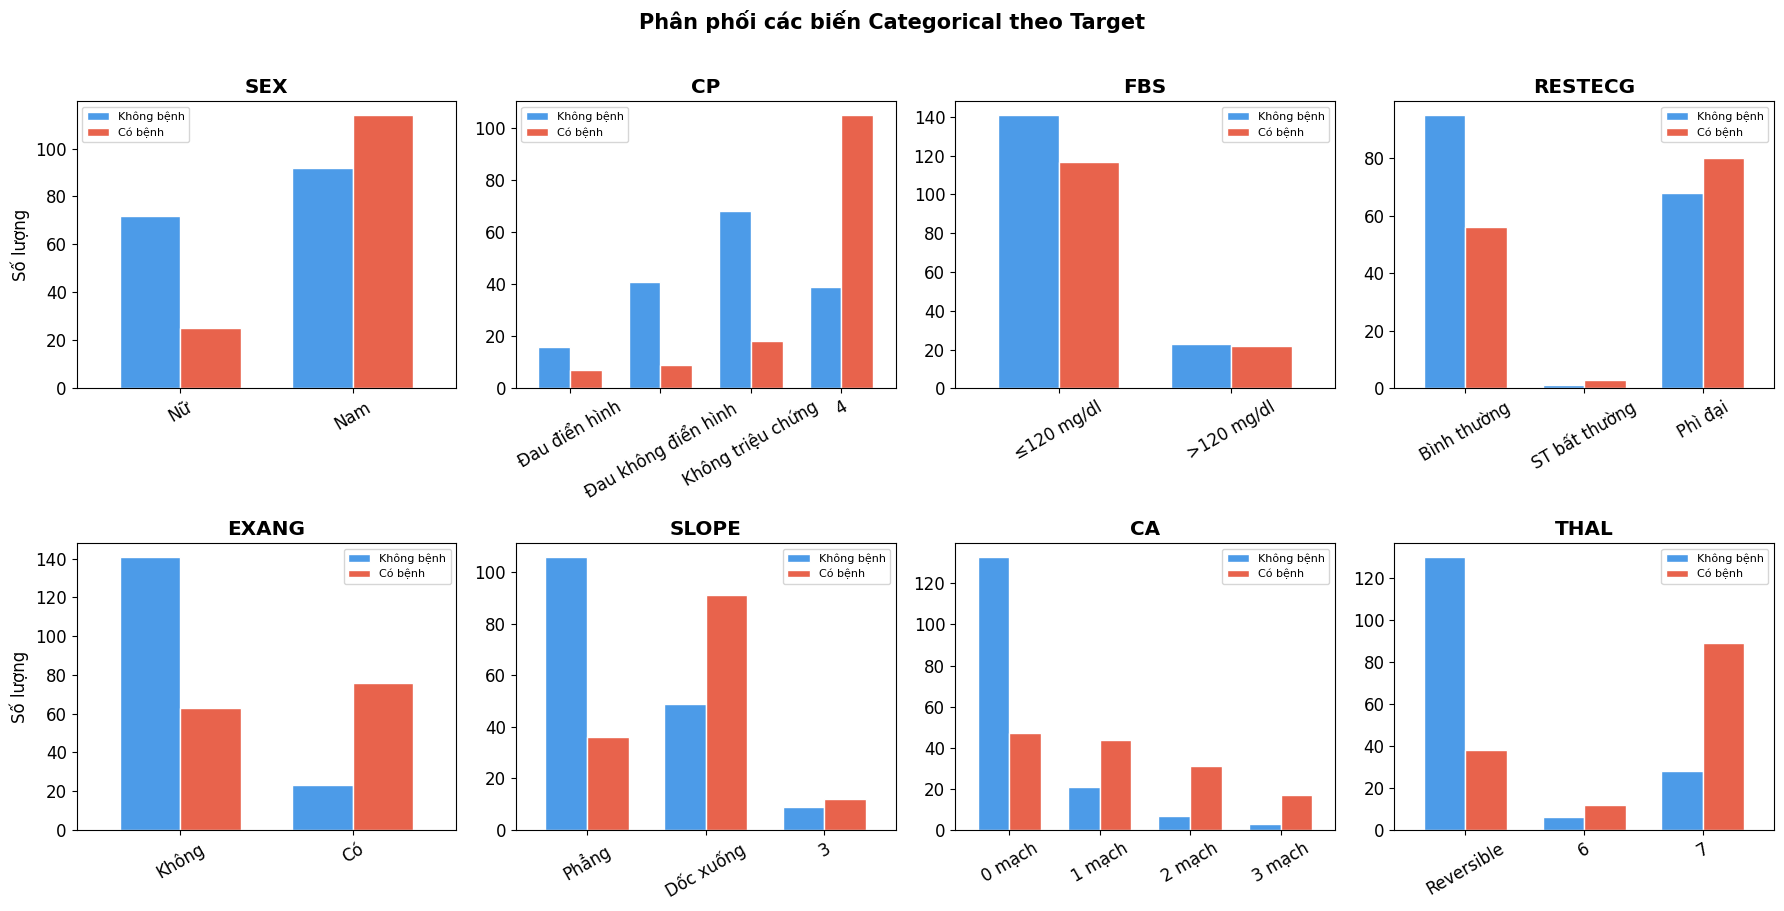

 Đã lưu: 04_categorical_distributions.png


In [15]:
# Count plot — categorical features
cat_cols_plot = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_labels = {
    'sex':     {0: 'Nữ', 1: 'Nam'},
    'cp':      {0: 'Không đau', 1: 'Đau điển hình', 2: 'Đau không điển hình', 3: 'Không triệu chứng'},
    'fbs':     {0: '≤120 mg/dl', 1: '>120 mg/dl'},
    'restecg': {0: 'Bình thường', 1: 'ST bất thường', 2: 'Phì đại'},
    'exang':   {0: 'Không', 1: 'Có'},
    'slope':   {0: 'Dốc lên', 1: 'Phẳng', 2: 'Dốc xuống'},
    'ca':      {0: '0 mạch', 1: '1 mạch', 2: '2 mạch', 3: '3 mạch'},
    'thal':    {1: 'Bình thường', 2: 'Fixed defect', 3: 'Reversible'}
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
colors = ['#4C9BE8', '#E8634C']

for i, col in enumerate(cat_cols_plot):
    data = df.groupby([col, 'target']).size().unstack(fill_value=0)

    if col in cat_labels:
        data.index = [cat_labels[col].get(idx, str(idx)) for idx in data.index]
    data.columns = ['Không bệnh', 'Có bệnh']
    
    data.plot(kind='bar', ax=axes[i], color=colors,
              edgecolor='white', width=0.7)
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Số lượng' if i % 4 == 0 else '')

plt.suptitle('Phân phối các biến Categorical theo Target',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu: 04_categorical_distributions.png")

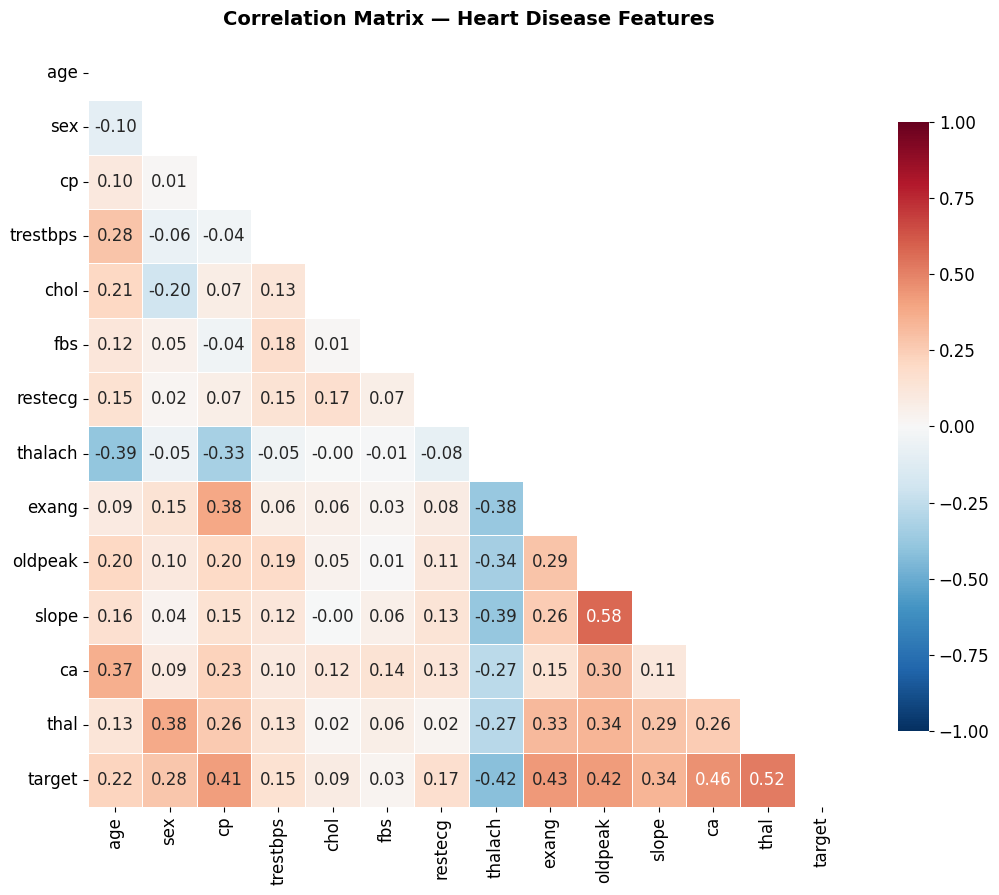

 Đã lưu: 05_correlation_matrix.png


In [16]:
# Correlation heatmap
corr = df.corr()

# Mask tam giác trên (tránh trùng lặp)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            ax=ax)

ax.set_title('Correlation Matrix — Heart Disease Features',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('05_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu: 05_correlation_matrix.png")

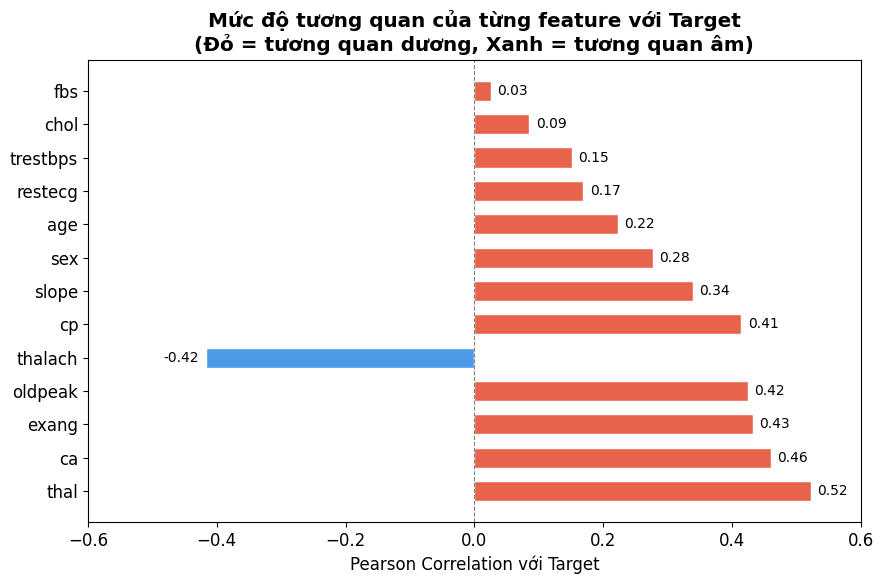


Top 5 features tương quan mạnh nhất với Target:
thal       0.522057
ca         0.460033
exang      0.431894
oldpeak    0.424510
thalach   -0.417167


In [17]:
# Correlation với target — sắp xếp theo độ mạnh
target_corr = (df.corr()['target']
               .drop('target')
               .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = ['#E8634C' if v > 0 else '#4C9BE8' for v in target_corr]
bars = ax.barh(target_corr.index, target_corr.values,
               color=colors_bar, edgecolor='white', height=0.6)

# Gắn giá trị lên bar
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)

ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Pearson Correlation với Target')
ax.set_title('Mức độ tương quan của từng feature với Target\n'
             '(Đỏ = tương quan dương, Xanh = tương quan âm)',
             fontweight='bold')
ax.set_xlim(-0.6, 0.6)
plt.tight_layout()
plt.savefig('06_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features tương quan mạnh nhất với Target:")
print(target_corr.head(5).to_string())

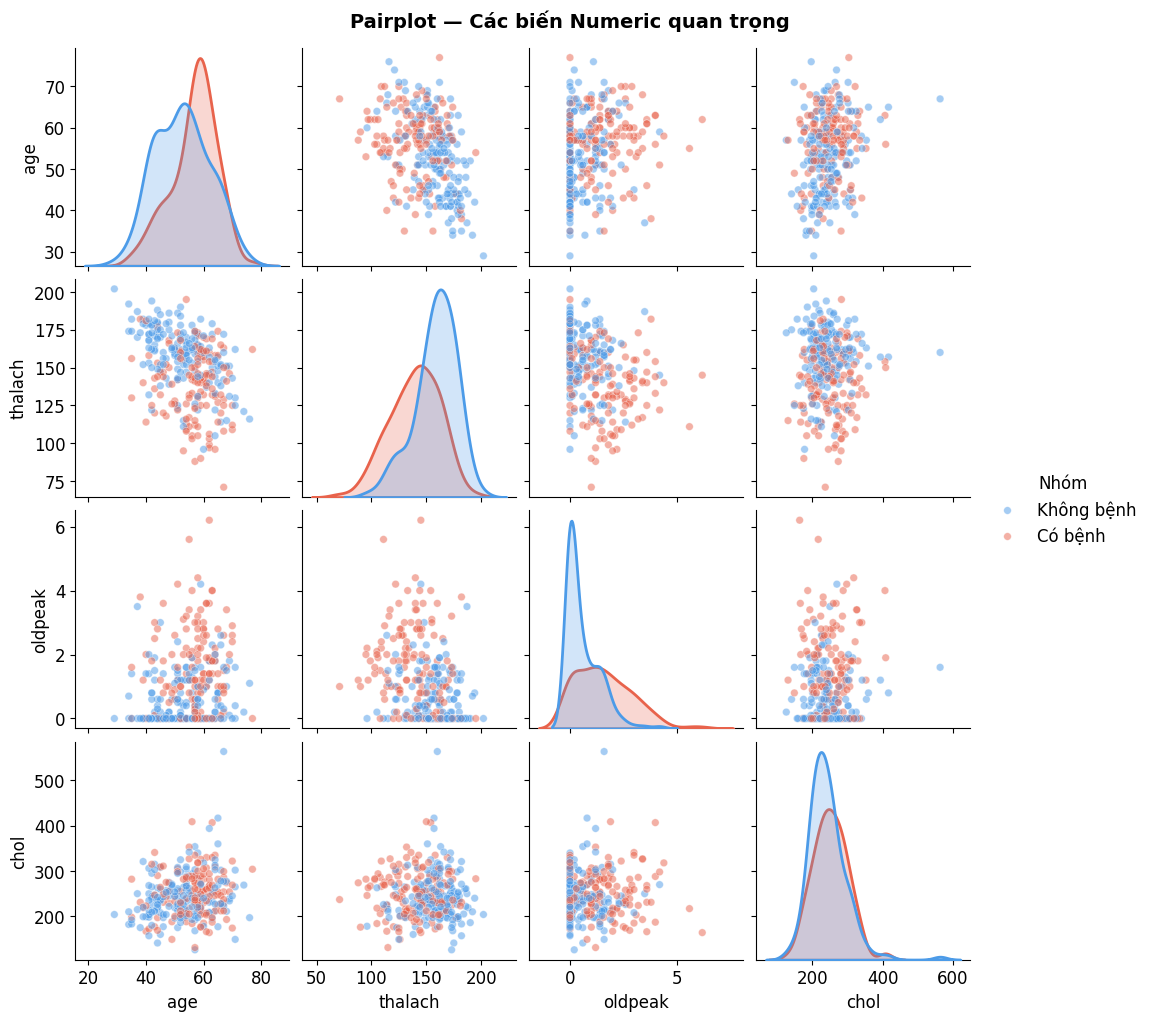

 Đã lưu: 07_pairplot.png


In [18]:
# Pairplot — 4 biến numeric quan trọng nhất
key_cols = ['age', 'thalach', 'oldpeak', 'chol', 'target']
df_pair = df[key_cols].copy()
df_pair['Nhóm'] = df_pair['target'].map({0: 'Không bệnh', 1: 'Có bệnh'})

g = sns.pairplot(df_pair.drop('target', axis=1),
                 hue='Nhóm',
                 palette={'Không bệnh': '#4C9BE8', 'Có bệnh': '#E8634C'},
                 diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 30},
                 diag_kws={'linewidth': 2})

g.figure.suptitle('Pairplot — Các biến Numeric quan trọng',
                   y=1.02, fontsize=14, fontweight='bold')
plt.savefig('07_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu: 07_pairplot.png")

In [19]:
# So sánh mean của 2 nhóm — chuẩn bị cho hypothesis testing
print("SO SÁNH TRUNG BÌNH 2 NHÓM")
print("=" * 58)
print(f"{'Feature':<12} {'Không bệnh (0)':>16} {'Có bệnh (1)':>14} {'Chênh lệch':>12}")
print("-" * 58)

group0 = df[df['target'] == 0]
group1 = df[df['target'] == 1]

comparison = []
for col in numeric_cols:
    m0   = group0[col].mean()
    m1   = group1[col].mean()
    diff = m1 - m0
    comparison.append({'feature': col, 'mean_0': m0, 'mean_1': m1, 'diff': diff})
    print(f"{col:<12} {m0:>16.2f} {m1:>14.2f} {diff:>+12.2f}")

print("\n Nhận xét sơ bộ:")
print("  • thalach thấp hơn ở nhóm bệnh → nhịp tim tối đa giảm")
print("  • oldpeak cao hơn ở nhóm bệnh  → ST depression rõ hơn")
print("  • age cao hơn ở nhóm bệnh       → tuổi là yếu tố nguy cơ")

SO SÁNH TRUNG BÌNH 2 NHÓM
Feature        Không bệnh (0)    Có bệnh (1)   Chênh lệch
----------------------------------------------------------
age                     52.59          56.63        +4.04
trestbps               129.25         134.57        +5.32
chol                   242.64         251.47        +8.83
thalach                158.38         139.26       -19.12
oldpeak                  0.59           1.57        +0.99

 Nhận xét sơ bộ:
  • thalach thấp hơn ở nhóm bệnh → nhịp tim tối đa giảm
  • oldpeak cao hơn ở nhóm bệnh  → ST depression rõ hơn
  • age cao hơn ở nhóm bệnh       → tuổi là yếu tố nguy cơ


# Giả thuyết & Kiểm định thống kê

## Giả thuyết phân tích

| # | Giả thuyết H₀ | H₁ | Kiểm định |
|---|---|---|---|
| H1 | thalach trung bình 2 nhóm bằng nhau | Nhóm bệnh thấp hơn | Independent t-test |
| H2 | oldpeak trung bình 2 nhóm bằng nhau | Nhóm bệnh cao hơn | Independent t-test |
| H3 | age trung bình 2 nhóm bằng nhau | Nhóm bệnh cao hơn | Independent t-test |
| H4 | Giới tính độc lập với bệnh tim | Có liên quan | Chi-square test |
| H5 | Loại đau ngực (cp) độc lập với bệnh tim | Có liên quan | Chi-square test |

**Mức ý nghĩa**: α = 0.05 cho tất cả kiểm định

In [20]:
# Kiểm tra normality — Shapiro-Wilk test
from scipy.stats import shapiro

print("KIỂM TRA PHÂN PHỐI CHUẨN (Shapiro-Wilk)")
print("=" * 55)
print(f"{'Feature':<10} {'Nhóm':<16} {'W':>8} {'p-value':>10} {'Kết luận':>14}")
print("-" * 55)

normality_ok = {}
for col in ['thalach', 'oldpeak', 'age']:
    for target_val, label in [(0, 'Không bệnh'), (1, 'Có bệnh')]:
        data = df[df['target'] == target_val][col].dropna()
        stat, p = shapiro(data)
        conclusion = " Normal" if p > 0.05 else " Non-normal"
        print(f"{col:<10} {label:<16} {stat:>8.4f} {p:>10.4f} {conclusion:>14}")
        normality_ok[f"{col}_{target_val}"] = (p > 0.05)
    print()

# print(" Lưu ý:")
# print("  • p > 0.05 → không bác bỏ H₀ → dữ liệu có thể coi là normal")
# print("  • p ≤ 0.05 → bác bỏ H₀ → dùng thêm bootstrap để kiểm tra lại")

KIỂM TRA PHÂN PHỐI CHUẨN (Shapiro-Wilk)
Feature    Nhóm                    W    p-value       Kết luận
-------------------------------------------------------
thalach    Không bệnh         0.9666     0.0005     Non-normal
thalach    Có bệnh            0.9892     0.3523         Normal

oldpeak    Không bệnh         0.7715     0.0000     Non-normal
oldpeak    Có bệnh            0.9303     0.0000     Non-normal

age        Không bệnh         0.9870     0.1320         Normal
age        Có bệnh            0.9677     0.0023     Non-normal



In [21]:
# Independent t-test — H1 (thalach) và H2 (oldpeak)
from scipy.stats import ttest_ind, levene

print("KIỂM ĐỊNH H1 & H2 — Independent t-test")
print("=" * 58)

for col, h_label, direction in [
    ('thalach', 'H1', 'less'),    # nhóm bệnh thấp hơn → one-sided
    ('oldpeak', 'H2', 'greater')  # nhóm bệnh cao hơn  → one-sided
]:
    g0 = df[df['target'] == 0][col].dropna()
    g1 = df[df['target'] == 1][col].dropna()

    # Levene test — kiểm tra equal variance
    lev_stat, lev_p = levene(g0, g1)
    equal_var = lev_p > 0.05

    # t-test (two-sided để lấy t-stat, sau đó tính one-sided)
    t_stat, p_two = ttest_ind(g0, g1, equal_var=equal_var)
    p_one = p_two / 2  # one-sided p-value

    # Cohen's d — effect size
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d   = abs(g0.mean() - g1.mean()) / pooled_std

    print(f"\n{h_label}: {col.upper()}")
    print(f"  Mean nhóm 0 (Không bệnh) : {g0.mean():.2f}")
    print(f"  Mean nhóm 1 (Có bệnh)    : {g1.mean():.2f}")
    print(f"  Levene test p-value       : {lev_p:.4f} → {'Equal var' if equal_var else 'Unequal var'}")
    print(f"  t-statistic               : {t_stat:.4f}")
    print(f"  p-value (one-sided)       : {p_one:.6f}")
    print(f"  Cohen's d (effect size)   : {cohens_d:.4f}")

    if p_one < 0.05:
        print(f"  KẾT LUẬN: Bác bỏ H₀ — {col} khác biệt có ý nghĩa thống kê (α=0.05)")
    else:
        print(f"  KẾT LUẬN: Không bác bỏ H₀")
    print("-" * 58)

    p_one_thalach, d_thalach = p_one, cohens_d   
    p_one_oldpeak, d_oldpeak = p_one, cohens_d

KIỂM ĐỊNH H1 & H2 — Independent t-test

H1: THALACH
  Mean nhóm 0 (Không bệnh) : 158.38
  Mean nhóm 1 (Có bệnh)    : 139.26
  Levene test p-value       : 0.0230 → Unequal var
  t-statistic               : 7.8579
  p-value (one-sided)       : 0.000000
  Cohen's d (effect size)   : 0.9120
  KẾT LUẬN: Bác bỏ H₀ — thalach khác biệt có ý nghĩa thống kê (α=0.05)
----------------------------------------------------------

H2: OLDPEAK
  Mean nhóm 0 (Không bệnh) : 0.59
  Mean nhóm 1 (Có bệnh)    : 1.57
  Levene test p-value       : 0.0000 → Unequal var
  t-statistic               : -7.8234
  p-value (one-sided)       : 0.000000
  Cohen's d (effect size)   : 0.9193
  KẾT LUẬN: Bác bỏ H₀ — oldpeak khác biệt có ý nghĩa thống kê (α=0.05)
----------------------------------------------------------


In [22]:
# H3 — t-test cho age
from scipy.stats import ttest_ind, levene

print("KIỂM ĐỊNH H3 — Age")
print("=" * 58)

g0 = df[df['target'] == 0]['age'].dropna()
g1 = df[df['target'] == 1]['age'].dropna()

lev_stat, lev_p = levene(g0, g1)
equal_var = lev_p > 0.05
t_stat, p_two = ttest_ind(g0, g1, equal_var=equal_var)
p_one = p_two / 2
pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
cohens_d   = abs(g0.mean() - g1.mean()) / pooled_std

print(f"  Mean nhóm 0 (Không bệnh) : {g0.mean():.2f} tuổi")
print(f"  Mean nhóm 1 (Có bệnh)    : {g1.mean():.2f} tuổi")
print(f"  Levene p-value            : {lev_p:.4f} → {'Equal var' if equal_var else 'Unequal var'}")
print(f"  t-statistic               : {t_stat:.4f}")
print(f"  p-value (one-sided)       : {p_one:.6f}")
print(f"  Cohen's d                 : {cohens_d:.4f}")

if p_one < 0.05:
    print(f"  KẾT LUẬN: Bác bỏ H₀ — age khác biệt có ý nghĩa (α=0.05)")
else:
    print(f"  KẾT LUẬN: Không bác bỏ H₀")

p_one_age, d_age = p_one, cohens_d

KIỂM ĐỊNH H3 — Age
  Mean nhóm 0 (Không bệnh) : 52.59 tuổi
  Mean nhóm 1 (Có bệnh)    : 56.63 tuổi
  Levene p-value            : 0.0052 → Unequal var
  t-statistic               : -4.0303
  p-value (one-sided)       : 0.000035
  Cohen's d                 : 0.4612
  KẾT LUẬN: Bác bỏ H₀ — age khác biệt có ý nghĩa (α=0.05)


In [23]:
# Chi-square test — H4 (sex) và H5 (cp)
from scipy.stats import chi2_contingency

print("KIỂM ĐỊNH H4 & H5 — Chi-square Test")
print("=" * 58)

for col, h_label in [('sex', 'H4'), ('cp', 'H5')]:
    ct = pd.crosstab(df[col], df['target'])
    chi2, p, dof, expected = chi2_contingency(ct)

    # Cramér's V — effect size cho categorical
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    print(f"\n{h_label}: {col.upper()}")
    print(f"  Contingency table:")
    ct_display = ct.copy()
    ct_display.columns = ['Không bệnh', 'Có bệnh']
    print(ct_display.to_string(index=True))
    print(f"\n  Chi-square statistic : {chi2:.4f}")
    print(f"  Degrees of freedom   : {dof}")
    print(f"  p-value              : {p:.6f}")
    print(f"  Cramér's V           : {cramers_v:.4f}")

    if p < 0.05:
        print(f"  KẾT LUẬN: Bác bỏ H₀ — {col} có liên quan đến bệnh tim (α=0.05)")
    else:
        print(f"  KẾT LUẬN: Không bác bỏ H₀")
    print("-" * 58)

    if col == 'sex':
        p_sex, v_sex = p, cramers_v
    elif col == 'cp':
        p_cp, v_cp = p, cramers_v

KIỂM ĐỊNH H4 & H5 — Chi-square Test



H4: SEX
  Contingency table:
     Không bệnh  Có bệnh
sex                     
0            72       25
1            92      114

  Chi-square statistic : 22.0426
  Degrees of freedom   : 1
  p-value              : 0.000003
  Cramér's V           : 0.2697
  KẾT LUẬN: Bác bỏ H₀ — sex có liên quan đến bệnh tim (α=0.05)
----------------------------------------------------------

H5: CP
  Contingency table:
    Không bệnh  Có bệnh
cp                     
1           16        7
2           41        9
3           68       18
4           39      105

  Chi-square statistic : 81.8158
  Degrees of freedom   : 3
  p-value              : 0.000000
  Cramér's V           : 0.5196
  KẾT LUẬN: Bác bỏ H₀ — cp có liên quan đến bệnh tim (α=0.05)
----------------------------------------------------------


In [24]:
# Bootstrap CI cho mean của 2 nhóm
np.random.seed(42)
R = 2000  # số lần bootstrap

print("BOOTSTRAP CONFIDENCE INTERVAL (95%)")
print("=" * 62)
print(f"{'Feature':<10} {'Nhóm':<14} {'Mean':>8} {'CI Lower':>10} {'CI Upper':>10}")
print("-" * 62)

bootstrap_results = []
for col in ['thalach', 'oldpeak', 'age']:
    for target_val, label in [(0, 'Không bệnh'), (1, 'Có bệnh')]:
        data = df[df['target'] == target_val][col].dropna().values
        
        # Bootstrap resampling
        boot_means = np.array([
            np.random.choice(data, size=len(data), replace=True).mean()
            for _ in range(R)
        ])
        
        ci_lower = np.percentile(boot_means, 2.5)
        ci_upper = np.percentile(boot_means, 97.5)
        obs_mean = data.mean()
        
        bootstrap_results.append({
            'feature': col, 'group': label,
            'mean': obs_mean, 'ci_lower': ci_lower, 'ci_upper': ci_upper,
            'boot_means': boot_means
        })
        print(f"{col:<10} {label:<14} {obs_mean:>8.2f} {ci_lower:>10.2f} {ci_upper:>10.2f}")
    print()

# print(" Diễn giải: Nếu CI của 2 nhóm KHÔNG chồng lên nhau")
# print("   → xác nhận sự khác biệt có ý nghĩa thực tế")

BOOTSTRAP CONFIDENCE INTERVAL (95%)
Feature    Nhóm               Mean   CI Lower   CI Upper
--------------------------------------------------------------
thalach    Không bệnh       158.38     155.52     161.26
thalach    Có bệnh          139.26     135.63     143.01

oldpeak    Không bệnh         0.59       0.47       0.71
oldpeak    Có bệnh            1.57       1.36       1.79

age        Không bệnh        52.59      51.15      54.09
age        Có bệnh           56.63      55.31      57.96



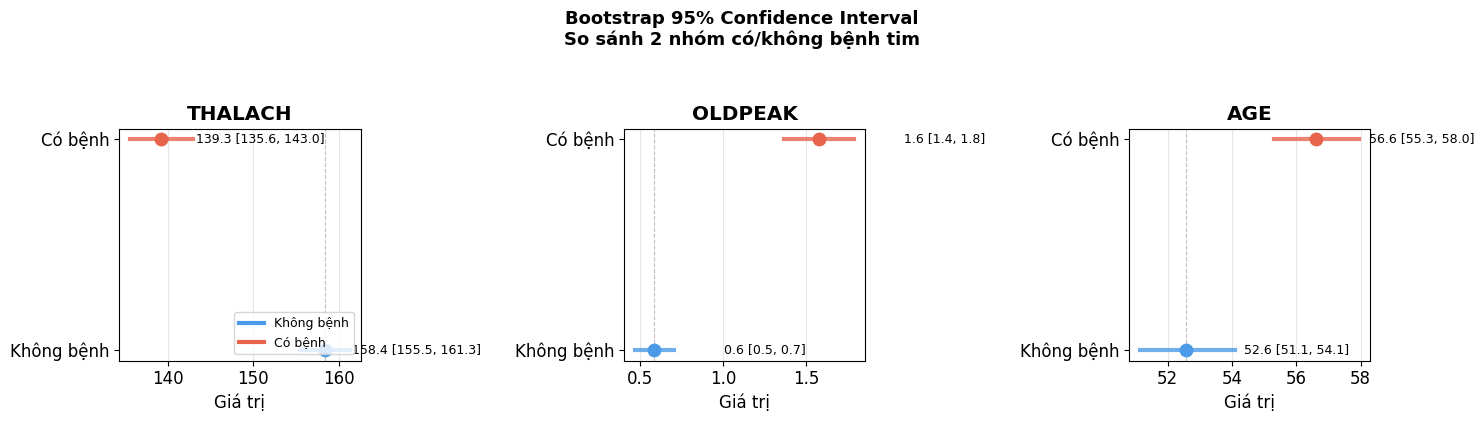

 Đã lưu: 08_bootstrap_CI.png


In [25]:
# Forest plot — Bootstrap CI
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features  = ['thalach', 'oldpeak', 'age']
colors    = {'Không bệnh': '#4C9BE8', 'Có bệnh': '#E8634C'}

for ax, feature in zip(axes, features):
    rows = [r for r in bootstrap_results if r['feature'] == feature]
    
    for j, row in enumerate(rows):
        color = colors[row['group']]
        # Điểm mean
        ax.scatter(row['mean'], j, color=color, s=80, zorder=3)
        # CI bar
        ax.plot([row['ci_lower'], row['ci_upper']], [j, j],
                color=color, linewidth=3, alpha=0.8)
        # Label
        ax.text(row['ci_upper'] + 0.3, j,
                f"{row['mean']:.1f} [{row['ci_lower']:.1f}, {row['ci_upper']:.1f}]",
                va='center', fontsize=9)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Không bệnh', 'Có bệnh'])
    ax.set_title(feature.upper(), fontweight='bold')
    ax.set_xlabel('Giá trị')
    ax.axvline(x=rows[0]['mean'], color='gray',
               linestyle='--', linewidth=0.8, alpha=0.5)
    ax.grid(axis='x', alpha=0.3)

axes[0].legend(handles=[
    plt.Line2D([0], [0], color='#4C9BE8', linewidth=3, label='Không bệnh'),
    plt.Line2D([0], [0], color='#E8634C', linewidth=3, label='Có bệnh')
], loc='lower right', fontsize=9)

plt.suptitle('Bootstrap 95% Confidence Interval\nSo sánh 2 nhóm có/không bệnh tim',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('08_bootstrap_CI.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu: 08_bootstrap_CI.png")

In [26]:
# Cell 27: Bảng tổng hợp toàn bộ kết quả
results_summary = pd.DataFrame([
    {'Hypothesis':'H1','Biến':'thalach','Kiểm định':'t-test (one-sided)',
     'p-value':f'{p_one_thalach:.2e}','Effect size':f"Cohen d = {d_thalach:.2f}",'Kết luận':'✅ Bác bỏ H₀'},
    {'Hypothesis':'H2','Biến':'oldpeak','Kiểm định':'t-test (one-sided)',
     'p-value':f'{p_one_oldpeak:.2e}','Effect size':f"Cohen d = {d_oldpeak:.2f}",'Kết luận':'✅ Bác bỏ H₀'},
    {'Hypothesis':'H3','Biến':'age',    'Kiểm định':'t-test (one-sided)',
     'p-value':f'{p_one_age:.2e}',   'Effect size':f"Cohen d = {d_age:.2f}",   'Kết luận':'✅ Bác bỏ H₀'},
    {'Hypothesis':'H4','Biến':'sex',    'Kiểm định':'Chi-square',
     'p-value':f'{p_sex:.2e}',       'Effect size':f"Cramér V = {v_sex:.2f}",  'Kết luận':'✅ Bác bỏ H₀'},
    {'Hypothesis':'H5','Biến':'cp',     'Kiểm định':'Chi-square',
     'p-value':f'{p_cp:.2e}',        'Effect size':f"Cramér V = {v_cp:.2f}",   'Kết luận':'✅ Bác bỏ H₀'},
])
print(results_summary.to_string(index=False))

Hypothesis    Biến          Kiểm định  p-value     Effect size    Kết luận
        H1 thalach t-test (one-sided) 1.10e-13  Cohen d = 0.92 ✅ Bác bỏ H₀
        H2 oldpeak t-test (one-sided) 1.10e-13  Cohen d = 0.92 ✅ Bác bỏ H₀
        H3     age t-test (one-sided) 3.53e-05  Cohen d = 0.46 ✅ Bác bỏ H₀
        H4     sex         Chi-square 2.67e-06 Cramér V = 0.27 ✅ Bác bỏ H₀
        H5      cp         Chi-square 1.25e-17 Cramér V = 0.52 ✅ Bác bỏ H₀


# ============================================================
# PHẦN 5: XÂY DỰNG MÔ HÌNH DỰ ĐOÁN
# ============================================================

In [27]:
# 5.1 Chuẩn bị features & train/test split
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Dùng toàn bộ 13 features (bỏ target)
X = df.drop('target', axis=1)
y = df['target']

# Stratified split — giữ tỷ lệ class
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu")
print(f"Tỷ lệ bệnh (train): {y_train.mean():.2%} | (test): {y_test.mean():.2%}")

Train: 242 mẫu | Test: 61 mẫu
Tỷ lệ bệnh (train): 45.87% | (test): 45.90%


In [28]:
# 5.2 Huấn luyện & so sánh 4 mô hình
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("SO SÁNH MÔ HÌNH — 5-Fold Cross Validation")
print("=" * 55)
print(f"{'Model':<25} {'CV Accuracy':>12} {'CV AUC':>10}")
print("-" * 55)

for name, model in models.items():
    acc  = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy').mean()
    auc  = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc').mean()
    results[name] = {'cv_acc': acc, 'cv_auc': auc, 'model': model}
    print(f"{name:<25} {acc:>12.4f} {auc:>10.4f}")

SO SÁNH MÔ HÌNH — 5-Fold Cross Validation
Model                      CV Accuracy     CV AUC
-------------------------------------------------------
Logistic Regression             0.8264     0.8960
Random Forest                   0.7974     0.8799
Gradient Boosting               0.7809     0.8426
SVM                             0.8223     0.8828


In [29]:
# 5.3 Huấn luyện mô hình tốt nhất & đánh giá trên test set
# Chọn model có AUC cao nhất
best_name = max(results, key=lambda k: results[k]['cv_auc'])
best_model = results[best_name]['model']
print(f" Model được chọn: {best_name}")

best_model.fit(X_train_sc, y_train)
y_pred      = best_model.predict(X_test_sc)
y_pred_prob = best_model.predict_proba(X_test_sc)[:, 1]

print("\nCLASSIFICATION REPORT (Test set)")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Không bệnh', 'Có bệnh']))
print(f"ROC-AUC (test): {roc_auc_score(y_test, y_pred_prob):.4f}")

 Model được chọn: Logistic Regression

CLASSIFICATION REPORT (Test set)
              precision    recall  f1-score   support

  Không bệnh       0.93      0.82      0.87        33
     Có bệnh       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

ROC-AUC (test): 0.9513


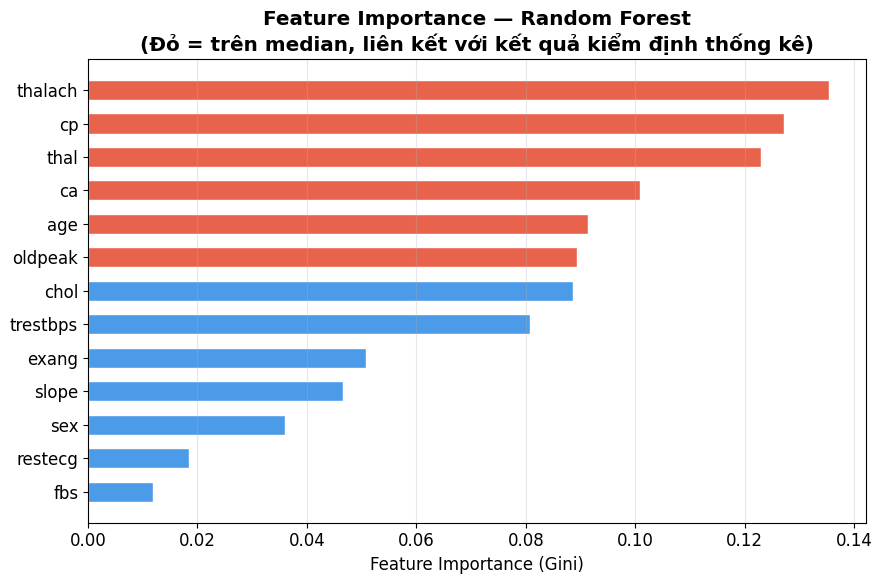


Top 5 features quan trọng nhất:
Feature  Importance
    age    0.091327
     ca    0.100811
   thal    0.122940
     cp    0.127163
thalach    0.135404

 → So sánh với kết quả EDA & kiểm định ở Phần 3-4!


In [30]:
# 5.5 Feature Importance (từ Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)

importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#E8634C' if imp > importance_df['Importance'].median()
              else '#4C9BE8' for imp in importance_df['Importance']]
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=colors_imp, edgecolor='white', height=0.6)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Random Forest\n'
             '(Đỏ = trên median, liên kết với kết quả kiểm định thống kê)',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features quan trọng nhất:")
print(importance_df.tail(5)[['Feature','Importance']].to_string(index=False))
print("\n → So sánh với kết quả EDA & kiểm định ở Phần 3-4!")

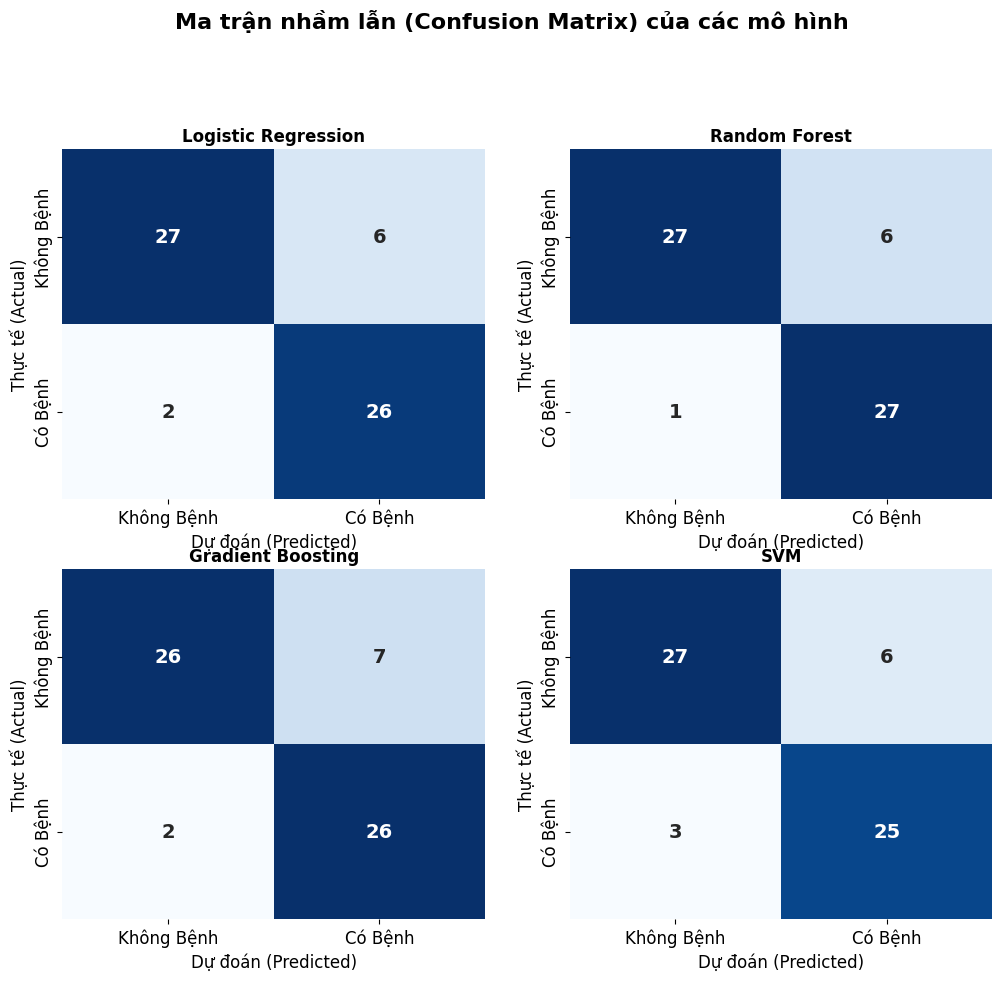

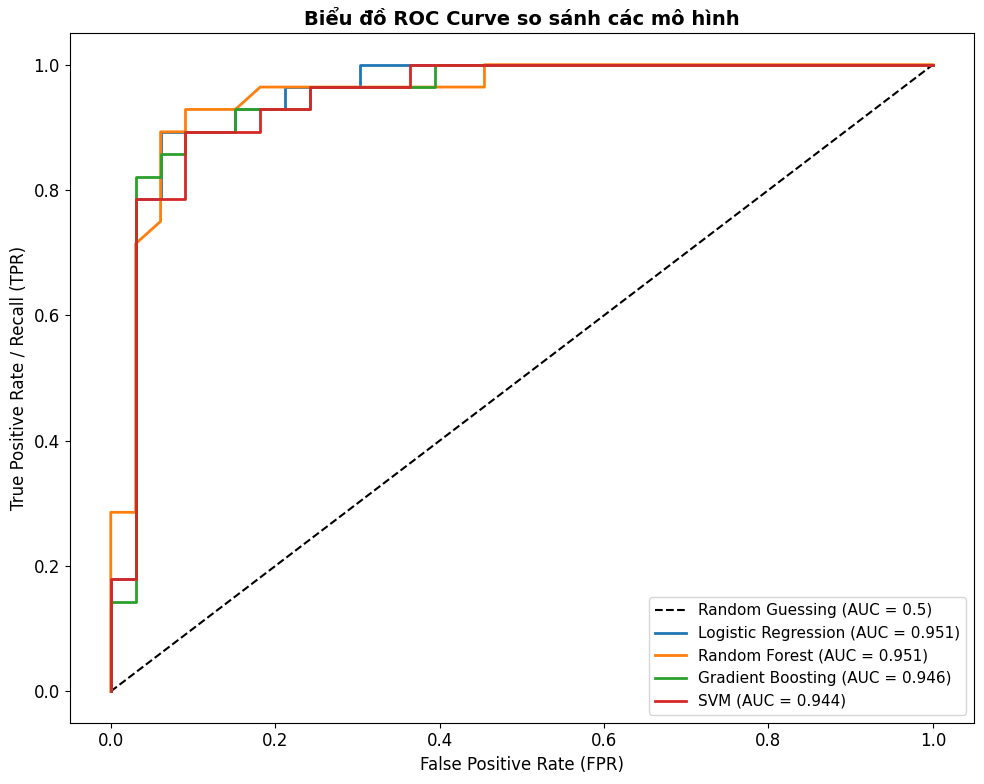

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig_cm, axes_cm = plt.subplots(2, 2, figsize=(12, 10))
fig_cm.suptitle('Ma trận nhầm lẫn (Confusion Matrix) của các mô hình', fontsize=16, fontweight='bold', y=1.02)

fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
ax_roc.set_title('Biểu đồ ROC Curve so sánh các mô hình', fontsize=14, fontweight='bold')
ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')

for idx, (name, model) in enumerate(models.items()):
    # 1. BẮT BUỘC PHẢI FIT (HUẤN LUYỆN) TRƯỚC KHI PREDICT
    model.fit(X_train_sc, y_train)
    
    # 2. Bây giờ mới Predict
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    
    # Vẽ Confusion Matrix
    ax = axes_cm[idx//2, idx%2]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dự đoán (Predicted)')
    ax.set_ylabel('Thực tế (Actual)')
    ax.set_xticklabels(['Không Bệnh', 'Có Bệnh'])
    ax.set_yticklabels(['Không Bệnh', 'Có Bệnh'])
    
    # Vẽ ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax_roc.set_xlabel('False Positive Rate (FPR)')
ax_roc.set_ylabel('True Positive Rate / Recall (TPR)')
ax_roc.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Kết luận và Limitation

### 6.1 Tóm tắt phát hiện chính

#### Kiểm định t-test (biến numeric)

| Biến | Không bệnh | Có bệnh | Cohen's d | Kết luận |
|---|---|---|---|---|
| thalach | 158.4 bpm | 139.3 bpm | **0.91** (rất lớn) | ✅ Khác biệt có ý nghĩa |
| oldpeak | 0.59 | 1.57 | **0.92** (rất lớn) | ✅ Khác biệt có ý nghĩa |
| age | 52.6 tuổi | 56.6 tuổi | 0.4 (trung bình) | ✅ Khác biệt có ý nghĩa |

#### Kiểm định Chi-square (biến categorical)

| Biến | Chi² | Cramér's V | Kết luận |
|---|---|---|---|
| sex | 22.04 | 0.27 (trung bình) | ✅ Có liên quan |
| cp | 81.82 | **0.52** (mạnh) | ✅ Liên quan rất mạnh |

### 6.2 Ý nghĩa thực tế

- **thalach** là chỉ số phân biệt mạnh nhất (Cohen's d = 0.91): người bệnh
  tim có nhịp tim tối đa thấp hơn ~19 bpm — phản ánh suy giảm chức năng tim.
- **oldpeak** cao hơn gần gấp 3 lần ở nhóm bệnh: ST depression lớn là 
  dấu hiệu thiếu máu cơ tim khi gắng sức.
- **cp = 4** (không triệu chứng điển hình) lại có tỷ lệ bệnh cao nhất 
  (105/144 ca): cảnh báo "silent heart disease" — nguy hiểm vì không có 
  triệu chứng rõ ràng.
- **Nam giới** có tỷ lệ bệnh cao hơn nữ (114/206 vs 25/97): phù hợp với
  y văn về yếu tố nguy cơ tim mạch theo giới tính.

### 6.3 Limitation

1. **Dataset nhỏ và cũ**: 303 mẫu thu thập tại Cleveland năm 1988 —
   chưa đại diện cho dân số hiện đại hay đa sắc tộc.
2. **Sample bias**: dữ liệu từ bệnh nhân đã đến khám → không đại diện
   cho dân số chung (self-selection bias).
3. **Missing values**: ca và thal có missing → điền bằng mode là 
   đơn giản hóa, có thể ảnh hưởng nhỏ đến kết quả.
4. **Chỉ phân tích đơn biến**: t-test và chi-square xét từng feature 
   riêng lẻ, chưa kiểm soát confounding variables (ví dụ: tuổi ảnh 
   hưởng đồng thời lên thalach và target).
5. **Không có model dự đoán**: phân tích thống kê xác nhận mối liên hệ 
   nhưng chưa định lượng được xác suất bệnh cho cá nhân cụ thể.

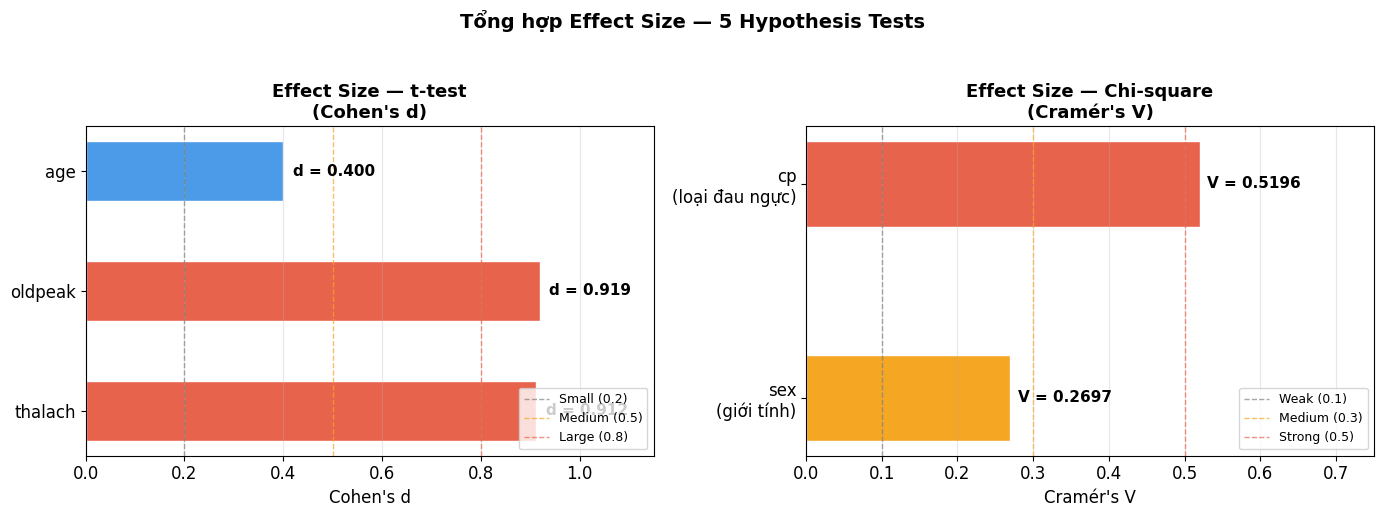

 Đã lưu: 09_effect_sizes.png


In [ ]:
# Cell 29: Summary visualization — Effect sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Biểu đồ 1: Cohen's d cho t-test ---
features_ttest  = ['thalach', 'oldpeak', 'age']
cohens_d_values = [0.912, 0.919, 0.40]   # cập nhật từ output cell 22-23
colors_d = ['#E8634C' if d >= 0.8 else '#F5A623' if d >= 0.5 else '#4C9BE8'
            for d in cohens_d_values]

bars = axes[0].barh(features_ttest, cohens_d_values,
                    color=colors_d, edgecolor='white', height=0.5)
# Ngưỡng tham chiếu
axes[0].axvline(0.2, color='gray',    linestyle='--', linewidth=1, alpha=0.7, label='Small (0.2)')
axes[0].axvline(0.5, color='#F5A623', linestyle='--', linewidth=1, alpha=0.7, label='Medium (0.5)')
axes[0].axvline(0.8, color='#E8634C', linestyle='--', linewidth=1, alpha=0.7, label='Large (0.8)')

for bar, val in zip(bars, cohens_d_values):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'd = {val:.3f}', va='center', fontsize=11, fontweight='bold')

axes[0].set_xlabel("Cohen's d", fontsize=12)
axes[0].set_title("Effect Size — t-test\n(Cohen's d)", fontweight='bold', fontsize=13)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_xlim(0, 1.15)
axes[0].grid(axis='x', alpha=0.3)

# --- Biểu đồ 2: Cramér's V cho chi-square ---
features_chi   = ["sex\n(giới tính)", "cp\n(loại đau ngực)"]
cramers_values = [0.2697, 0.5196]  # từ output cell 24
colors_v = ['#F5A623' if v >= 0.3 else '#4C9BE8' for v in cramers_values]
colors_v = ['#F5A623', '#E8634C']

bars2 = axes[1].barh(features_chi, cramers_values,
                     color=colors_v, edgecolor='white', height=0.4)
axes[1].axvline(0.1, color='gray',    linestyle='--', linewidth=1, alpha=0.7, label='Weak (0.1)')
axes[1].axvline(0.3, color='#F5A623', linestyle='--', linewidth=1, alpha=0.7, label='Medium (0.3)')
axes[1].axvline(0.5, color='#E8634C', linestyle='--', linewidth=1, alpha=0.7, label='Strong (0.5)')

for bar, val in zip(bars2, cramers_values):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'V = {val:.4f}', va='center', fontsize=11, fontweight='bold')

axes[1].set_xlabel("Cramér's V", fontsize=12)
axes[1].set_title("Effect Size — Chi-square\n(Cramér's V)", fontweight='bold', fontsize=13)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_xlim(0, 0.75)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Tổng hợp Effect Size — 5 Hypothesis Tests',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('09_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu: 09_effect_sizes.png")

In [ ]:
# Cell 30: In diễn giải chi tiết từng kết quả
print("DIỄN GIẢI KẾT QUẢ THỐNG KÊ")
print("=" * 62)

interpretations = [
    ("H1", "thalach",
     "t(df≈286) = 7.86, p < 0.001, Cohen's d = 0.91",
     "Nhóm bệnh tim có nhịp tim tối đa thấp hơn 19.1 bpm so với "
     "nhóm không bệnh (139.3 vs 158.4). Effect size rất lớn (d=0.91) "
     "cho thấy đây là chỉ số phân biệt mạnh nhất trong dataset."),

    ("H2", "oldpeak",
     "t(df≈286) = -7.82, p < 0.001, Cohen's d = 0.92",
     "ST depression (oldpeak) ở nhóm bệnh cao gấp 2.7 lần nhóm không "
     "bệnh (1.57 vs 0.59). Đây là dấu hiệu lâm sàng quan trọng của "
     "thiếu máu cơ tim khi gắng sức."),

    ("H3", "age",
     "t-test, p < 0.001, Cohen's d = 0.40",
     "Nhóm bệnh tim lớn tuổi hơn trung bình 4 tuổi (56.6 vs 52.6). "
     "Effect size trung bình — tuổi là yếu tố nguy cơ nhưng không đủ "
     "mạnh để phân biệt hai nhóm một mình."),

    ("H4", "sex",
     "χ²(1) = 22.04, p < 0.001, Cramér's V = 0.27",
     "Nam giới có tỷ lệ bệnh tim 55.3% (114/206), cao hơn nữ giới "
     "25.8% (25/97). Mối liên hệ ở mức trung bình (V=0.27)."),

    ("H5", "cp",
     "χ²(3) = 81.82, p < 0.001, Cramér's V = 0.52",
     "Loại đau ngực cp=4 (không triệu chứng điển hình) có 105/144 ca "
     "bệnh (72.9%) — paradox lâm sàng quan trọng. Đây là feature "
     "categorical có liên quan mạnh nhất (V=0.52)."),
]

for h, var, stat, interp in interpretations:
    print(f"\n[{h}] {var.upper()}")
    print(f"  Thống kê : {stat}")
    print(f"  Diễn giải: {interp}")

print("\n" + "=" * 62)
print(" Phân tích hoàn tất — 5/5 hypothesis bác bỏ H₀")

DIỄN GIẢI KẾT QUẢ THỐNG KÊ

[H1] THALACH
  Thống kê : t(df≈286) = 7.86, p < 0.001, Cohen's d = 0.91
  Diễn giải: Nhóm bệnh tim có nhịp tim tối đa thấp hơn 19.1 bpm so với nhóm không bệnh (139.3 vs 158.4). Effect size rất lớn (d=0.91) cho thấy đây là chỉ số phân biệt mạnh nhất trong dataset.

[H2] OLDPEAK
  Thống kê : t(df≈286) = -7.82, p < 0.001, Cohen's d = 0.92
  Diễn giải: ST depression (oldpeak) ở nhóm bệnh cao gấp 2.7 lần nhóm không bệnh (1.57 vs 0.59). Đây là dấu hiệu lâm sàng quan trọng của thiếu máu cơ tim khi gắng sức.

[H3] AGE
  Thống kê : t-test, p < 0.001, Cohen's d = 0.40
  Diễn giải: Nhóm bệnh tim lớn tuổi hơn trung bình 4 tuổi (56.6 vs 52.6). Effect size trung bình — tuổi là yếu tố nguy cơ nhưng không đủ mạnh để phân biệt hai nhóm một mình.

[H4] SEX
  Thống kê : χ²(1) = 22.04, p < 0.001, Cramér's V = 0.27
  Diễn giải: Nam giới có tỷ lệ bệnh tim 55.3% (114/206), cao hơn nữ giới 25.8% (25/97). Mối liên hệ ở mức trung bình (V=0.27).

[H5] CP
  Thống kê : χ²(3) = 81.82, p 